In [ ]:
import pandas as pd

df = pd.read_csv("customer_support_text_classification.csv")

text_col = "customer_message"
target_col = "sentiment_label"

print("First 5 rows:")
print(df.head())

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("Columns:")
print(df.columns)

print("Missing values:")
print(df.isnull().sum())

print("Sample messages:")
print(df[text_col].head())

print("Class distribution:")
print(df[target_col].value_counts())

df["text_length"] = df[text_col].astype(str).apply(len)
print("Average text length:")
print(df["text_length"].mean())

First 5 rows:
  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  
Number of rows: 1500
Number of columns: 6
Columns:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='str')
Missing values:
ticket_id           0
channel             0
customer_message    0
sentiment_la

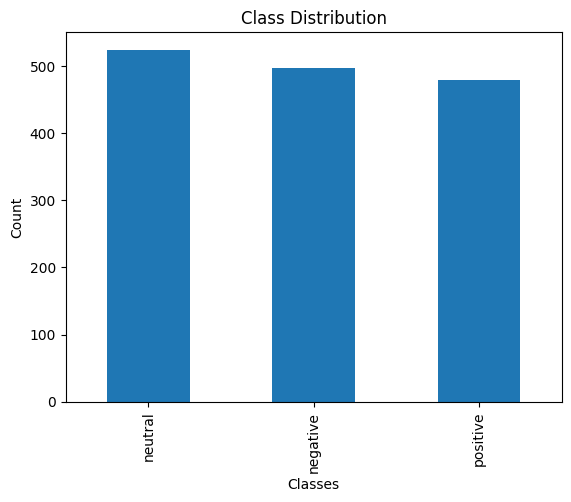

In [31]:
import matplotlib.pyplot as plt

df[target_col].value_counts().plot(kind='bar')

plt.title("Class Distribution")

plt.xlabel("Classes")
plt.ylabel("Count")

plt.show()

In [ ]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

df["clean_text"] = df[text_col].apply(clean_text)

print(df["clean_text"].head())

0    i need information about the payment process m...
1         i need information about the payment process
2    the refund process was fast and convenient i a...
3    my refund is still pending and this experience...
4      please tell me how to update my account details
Name: clean_text, dtype: str


In [33]:
df["tokens"] = df["clean_text"].apply(lambda x: x.split())

print(df["tokens"].head())

0    [i, need, information, about, the, payment, pr...
1    [i, need, information, about, the, payment, pr...
2    [the, refund, process, was, fast, and, conveni...
3    [my, refund, is, still, pending, and, this, ex...
4    [please, tell, me, how, to, update, my, accoun...
Name: tokens, dtype: object


In [52]:

stopwords = ["i", "my", "is", "the", "and", "a", "an", "to", "of", "in", "me", "was","this"]

df["tokens"] = df["tokens"].apply(
    lambda words: [word for word in words if word not in stopwords]
)

print(df["tokens"].head())

0    [need, information, about, payment, process, t...
1         [need, information, about, payment, process]
2    [refund, process, fast, convenient, appreciate...
3    [refund, still, pending, experience, frustrati...
4        [please, tell, how, update, account, details]
Name: tokens, dtype: object


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

df["final_text"] = df["tokens"].apply(lambda x: " ".join(x))

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["final_text"])

y = df[target_col]

print("Vector Shape:", X.shape)

#Machine learning models cannot understand raw text directly.

#Text must be converted into numerical vectors so the model can process patterns mathematically.

#TF-IDF gives importance to important words while reducing the importance of common words.

Vector Shape: (1500, 180)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



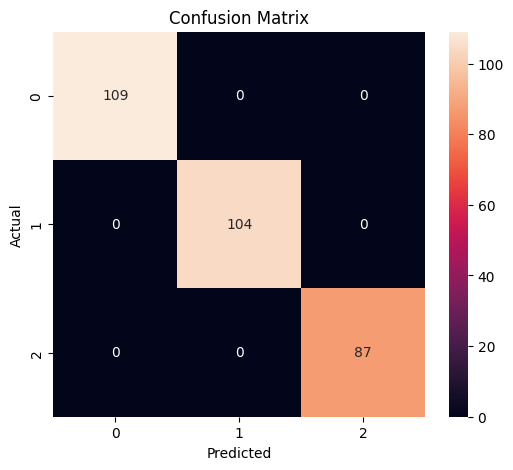

In [36]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df["final_text"])

sequences = tokenizer.texts_to_sequences(df["final_text"])

X_seq = pad_sequences(sequences, maxlen=50)

print(X_seq.shape)

(1500, 50)


In [38]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

lstm_model = Sequential()

lstm_model.add(Embedding(input_dim=5000, output_dim=64))

lstm_model.add(LSTM(64))

lstm_model.add(Dense(len(set(y_encoded)), activation='softmax'))

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.7073 - loss: 0.9649 - val_accuracy: 0.8833 - val_loss: 0.6109
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9698 - loss: 0.2310 - val_accuracy: 1.0000 - val_loss: 0.0289
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 0.0098 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 0.0015


In [42]:
loss, accuracy = lstm_model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0015
Test Accuracy: 1.0


In [43]:
#Explanation : 
#The LSTM model processes text as sequences of words instead of independent words.

#The embedding layer converts words into dense numerical vectors.

#The LSTM layer remembers previous words in the sequence, helping the model understand context better.